In [66]:
##### Compiles data for just the US

import os
import pandas as pd
import geopandas as gpd
import rasterio
from pathlib import Path
from rasterio.mask import mask
from shapely.geometry import box
from functools import reduce
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
# Get the current working directory
cd = Path.cwd().parent 

In [68]:
##### Geographies

input = gpd.read_file(f"{cd}/Data/Clean/Geographies/subnational_total.shp")
output = f"{cd}/Data/Misc./COMPS/USA_subnational_geography.shp"

input = input[input['ISO3'] == 'USA']
input.to_csv(output, index=False)

In [69]:
##### Capital intensities data 

input = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_capital_intensity.csv")
output = f"{cd}/Data/Misc./COMPS/USA_subnational_capital_intensities.csv"

input['ISO3'] = input['PROJ_ID'].str[:3]

input = input[input['ISO3'] == 'USA']
input.to_csv(output, index=False)

In [70]:
##### Labor intensities data 

input = pd.read_csv(f"{cd}/Data/Clean/Intensities/subnational_labor_intensity.csv")
output = f"{cd}/Data/Misc./COMPS/USA_subnational_labor_intensities.csv"

input['ISO3'] = input['PROJ_ID'].str[:3]

input = input[input['ISO3'] == 'USA']
input.to_csv(output, index=False)

In [71]:
##### County intensities data 

input = pd.read_csv(f"{cd}/Data/Clean/Intensities/country_intensities.csv")
output = f"{cd}/Data/Misc./COMPS/USA_intensities.csv"

input = input[input['ISO3'] == 'USA']
input.to_csv(output, index=False)

In [72]:
##### Predictor data (vectors)

def filter_usa_vectors(cd):
    input_dir = f"{cd}/Data/Clean/Predictors/Vectors"
    output_dir = f"{cd}/Data/Misc./COMPS/Predictors/Vector"
    os.makedirs(output_dir, exist_ok=True)

    for filename in os.listdir(input_dir):
        if filename.endswith(".csv"):
            df = pd.read_csv(os.path.join(input_dir, filename))
            df['ISO3'] = df['PROJ_ID'].str[:3]
            df = df[df['ISO3'] == 'USA']
            df.to_csv(os.path.join(output_dir, filename), index=False)

filter_usa_vectors(cd)

In [73]:
##### Predictor data (Rasters)

def clip_usa_rasters(cd):
    input_dir = f"{cd}/Data/Clean/Predictors/Rasters"
    output_dir = f"{cd}/Data/Misc./COMPS/Predictors/Raster"
    os.makedirs(output_dir, exist_ok=True)

    usa_bbox = box(-180, 18, -65, 72)

    for filename in os.listdir(input_dir):
        if filename.endswith(".tif") or filename.endswith(".tiff"):
            input_path = os.path.join(input_dir, filename)
            output_path = os.path.join(output_dir, filename)

            with rasterio.open(input_path) as src:
                clipped, transform = mask(src, [usa_bbox], crop=True)
                profile = src.profile.copy()  # copy first
                profile.update(               # then update
                    height=clipped.shape[1],
                    width=clipped.shape[2],
                    transform=transform
                )

            with rasterio.open(output_path, 'w', **profile) as dst:
                dst.write(clipped)

clip_usa_rasters(cd)

In [74]:
##### Combine into master sub-national dfs

### Predictors  
def merge_vector_csvs(cd):
    vector_dir = f"{cd}/Data/Misc./COMPS/Predictors/Vector"
    
    dfs = [
        pd.read_csv(os.path.join(vector_dir, f)).drop(columns='ISO3')
        for f in os.listdir(vector_dir)
        if f.endswith(".csv")
    ]

    merged = reduce(lambda left, right: pd.merge(left, right, on='PROJ_ID', how='outer'), dfs)
    
    return merged

predictors = merge_vector_csvs(cd)

### Capital 
capital = pd.read_csv(f"{cd}/Data/Misc./COMPS/USA_subnational_capital_intensities.csv")

capital = capital.merge(predictors, on='PROJ_ID', how='outer')

capital['STATE_ID'] = capital['PROJ_ID'].str[4:6]
capital['log_capital_intensity_USD_per_USD'] = np.log(capital['capital_intensity_USD_per_USD'])

### Labor 
labor = pd.read_csv(f"{cd}/Data/Misc./COMPS/USA_subnational_labor_intensities.csv")

labor = labor.merge(predictors, on='PROJ_ID', how='outer')

labor['STATE_ID'] = labor['PROJ_ID'].str[4:6]
labor['log_labor_intensity_jobs_per_million_USD'] = np.log(labor['labor_intensity_jobs_per_million_USD'])

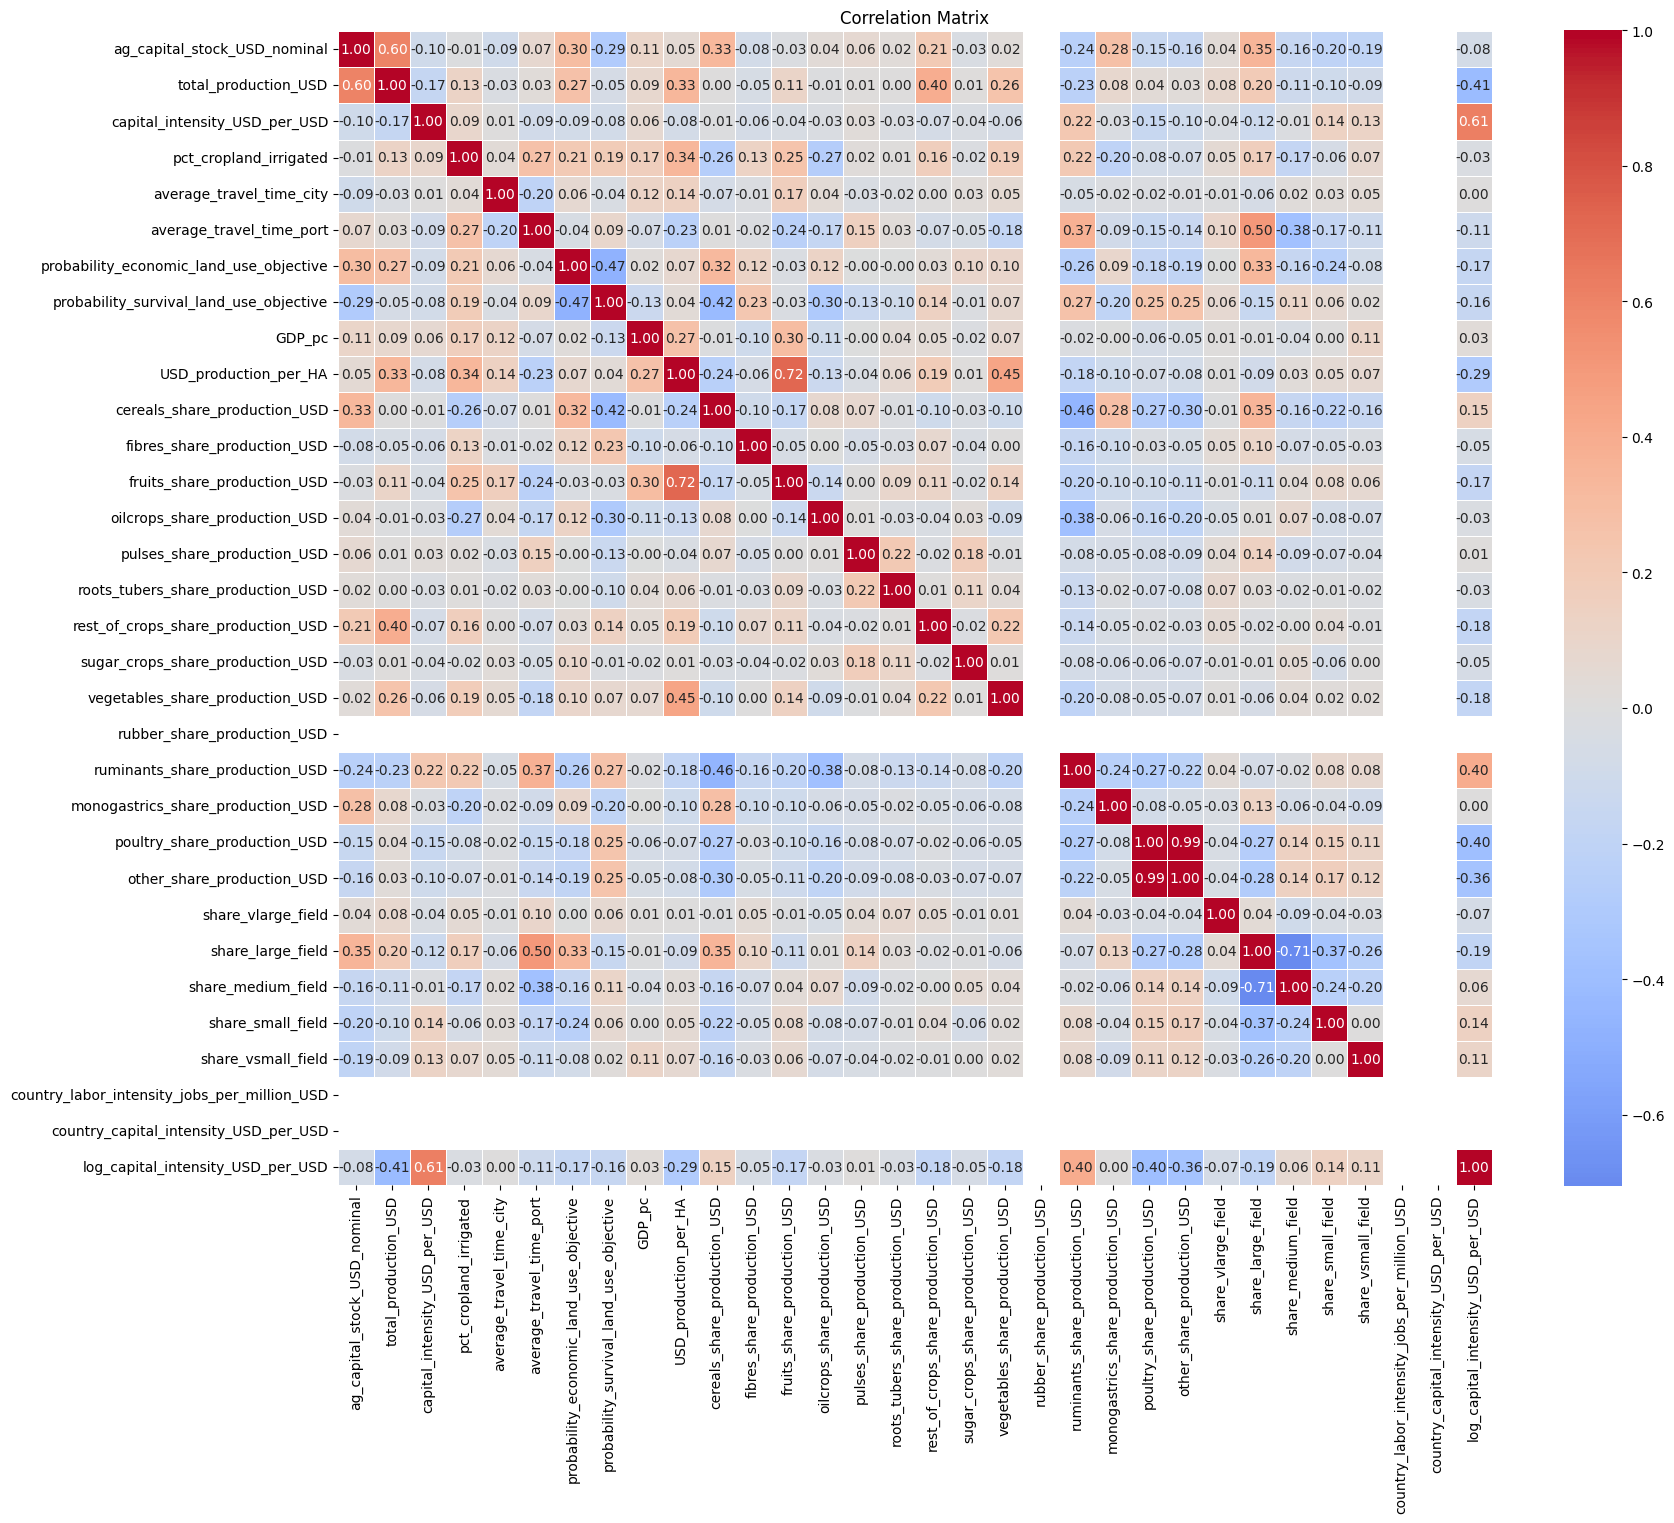

Top 10 most correlated pairs:
                                   var1                                    var2  correlation
           poultry_share_production_USD              other_share_production_USD     0.993343
                  USD_production_per_HA             fruits_share_production_USD     0.724599
                      share_large_field                      share_medium_field    -0.705295
          capital_intensity_USD_per_USD       log_capital_intensity_USD_per_USD     0.613731
           ag_capital_stock_USD_nominal                    total_production_USD     0.600819
               average_travel_time_port                       share_large_field     0.501088
probability_economic_land_use_objective probability_survival_land_use_objective    -0.472530
           cereals_share_production_USD          ruminants_share_production_USD    -0.462707
                  USD_production_per_HA         vegetables_share_production_USD     0.446573
probability_survival_land_use_objective 

In [76]:
##### Correlation plot to identify highly correlated pairs to drop 

def analyze_correlations(df):
    # Drop ID columns
    cols = df.select_dtypes(include='number').columns.tolist()
    corr = df[cols].corr()

    # Plot
    fig, ax = plt.subplots(figsize=(18, 15))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=0.5, ax=ax)
    ax.set_title('Correlation Matrix')
    plt.tight_layout()
    plt.show()

    # Rank pairs
    pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
            .stack()
            .reset_index()
    )
    pairs.columns = ['var1', 'var2', 'correlation']
    pairs['abs_correlation'] = pairs['correlation'].abs()
    pairs = pairs.sort_values('abs_correlation', ascending=False).drop(columns='abs_correlation')
    
    print("Top 10 most correlated pairs:")
    print(pairs.head(10).to_string(index=False))
    
    return pairs

pairs = analyze_correlations(capital)

In [77]:
####  Drop highly correlated pairs

# selected one half of each pair with correlation coefficient above 0.6
# other_share_production_USD, fruits_share_production_USD, share_medium_field

# capital 
col_to_keep = ['PROJ_ID', 'STATE_ID', 'log_capital_intensity_USD_per_USD',
       'pct_cropland_irrigated', 'average_travel_time_city',
       'average_travel_time_port', 'probability_economic_land_use_objective',
       'probability_survival_land_use_objective', 'GDP_pc',
       'USD_production_per_HA', 'cereals_share_production_USD',
       'fibres_share_production_USD',
       'oilcrops_share_production_USD', 'pulses_share_production_USD',
       'roots_tubers_share_production_USD',
       'rest_of_crops_share_production_USD',
       'sugar_crops_share_production_USD', 'vegetables_share_production_USD',
       'rubber_share_production_USD', 'ruminants_share_production_USD',
       'monogastrics_share_production_USD', 'poultry_share_production_USD',
       'share_vlarge_field', 'share_large_field',
       'share_small_field', 'share_vsmall_field']

capital = capital[col_to_keep]
capital = capital.dropna()

capital.to_csv(f"{cd}/Data/Misc./COMPS/USA_CAPITAL_MASTER.csv", index=False)

# labor 
col_to_keep = ['PROJ_ID', 'STATE_ID', 'log_labor_intensity_jobs_per_million_USD',
       'pct_cropland_irrigated', 'average_travel_time_city',
       'average_travel_time_port', 'probability_economic_land_use_objective',
       'probability_survival_land_use_objective', 'GDP_pc',
       'USD_production_per_HA', 'cereals_share_production_USD',
       'fibres_share_production_USD',
       'oilcrops_share_production_USD', 'pulses_share_production_USD',
       'roots_tubers_share_production_USD',
       'rest_of_crops_share_production_USD',
       'sugar_crops_share_production_USD', 'vegetables_share_production_USD',
       'rubber_share_production_USD', 'ruminants_share_production_USD',
       'monogastrics_share_production_USD', 'poultry_share_production_USD',
       'share_vlarge_field', 'share_large_field',
       'share_small_field', 'share_vsmall_field']

labor = labor[col_to_keep]
labor = labor.dropna()

labor.to_csv(f"{cd}/Data/Misc./COMPS/USA_LABOR_MASTER.csv", index=False)